# Perioperative Biosignal Preprocessing, Outlier Detection & Feature Engineering Pipeline

## Overview
This notebook implements an end-to-end, clinically validated data preprocessing and target generation pipeline for high-resolution perioperative patient telemetry records (VitalDB dataset).

### Clinical Background & Engineering Rationale:
1. **Physiological Plausibility Range Filtering (Hard Bounds)**: Rejects sensor disconnection codes (`-49.0`, `-32768`), saturated sensors, and non-physiological readings.
2. **Waveform Artifact Rejection**: Cleans `SNUADC/ECG_II` (rejecting electrocautery surgical noise) and `SNUADC/PLETH` (rejecting optical disconnects).
3. **Cross-Signal Hemodynamic Hierarchy & Consistency**:
   - Enforces the strict physiological hierarchy: $\text{ART\_SBP} > \text{ART\_MBP} > \text{ART\_DBP}$.
   - Validates Pulse Pressure: $10 \le (\text{SBP} - \text{DBP}) \le 160\text{ mmHg}$ to detect transducer damping, closed stopcocks, or line flushes.
   - Reconstructs missing MBP via $\text{DBP} + \frac{\text{SBP}-\text{DBP}}{3}$ when SBP & DBP are valid.
4. **Transient Spike / Jump Rejection**: Detects isolated 1-2 second transient jumps (surgical touch, motion) without distorting true physiological state shifts.
5. **Causal Missing Data Imputation**: Imputes 0.5 Hz vitals sampling gaps via forward-fill (limit 60s) without backward lookahead bias.
6. **Clinical Biomarker & Dynamic Feature Engineering**:
   - Hemodynamic Indices: Pulse Pressure, Shock Index ($HR/SBP$), Modified Shock Index ($HR/MBP$), Rate Pressure Product ($HR \times SBP / 100$).
   - Multi-scale dynamics: 60-second rolling averages, standard deviation (variability), and deltas (rate of change).
7. **Leakage-Free Adverse Event Target Labeling**:
   - Preserves `NaN` when vitals are unmonitored (preventing false negative data poisoning).
   - Calculates rolling forward-looking window (e.g. 600s / 10 minutes) maximum event labels for Hypotension, Tachycardia, and Hypoxia.
8. **High-Performance Multi-Core Parallel Processing**: Scales processing across all available CPU cores using `ProcessPoolExecutor` with real-time `tqdm` progress tracking.

In [1]:
import os
import glob
import time
import numpy as np
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Dynamically resolve project directory and data paths
base_dir = os.getcwd()
if os.path.basename(base_dir) == "process":
    project_root = os.path.abspath(os.path.join(base_dir, ".."))
    input_dir = os.path.join(project_root, "patient_raw_data")
    output_dir = base_dir
elif os.path.exists(os.path.join(base_dir, "patient_raw_data")):
    project_root = base_dir
    input_dir = os.path.join(base_dir, "patient_raw_data")
    output_dir = os.path.join(base_dir, "process")
elif os.path.exists(os.path.join(base_dir, "..", "patient_raw_data")):
    project_root = os.path.abspath(os.path.join(base_dir, ".."))
    input_dir = os.path.join(project_root, "patient_raw_data")
    output_dir = os.path.join(project_root, "process")
else:
    input_dir = "patient_raw_data"
    output_dir = "process"

os.makedirs(output_dir, exist_ok=True)
csv_files = sorted(glob.glob(os.path.join(input_dir, "*.csv")))
print(f"[Pipeline Init] Found {len(csv_files)} patient records in: {input_dir}")
print(f"[Pipeline Init] Output directory: {output_dir}")


[Pipeline Init] Found 3765 patient records in: /home/logan78/Desktop/SiLabs/patient_raw_data
[Pipeline Init] Output directory: /home/logan78/Desktop/SiLabs/process


## 1. Clinical Thresholds & Outlier Bounds Configuration

In [2]:
# 1. Physiological Plausibility Range (Hard Bounds)
bounds = {
    'Solar8000/HR': (20, 250),          # Heart Rate (bpm)
    'Solar8000/ART_SBP': (30, 300),     # Arterial Systolic Blood Pressure (mmHg)
    'Solar8000/ART_DBP': (10, 200),     # Arterial Diastolic Blood Pressure (mmHg)
    'Solar8000/ART_MBP': (20, 250),     # Arterial Mean Blood Pressure (mmHg)
    'Solar8000/PLETH_SPO2': (50, 100),  # Oxygen Saturation (%)
    'Solar8000/RR_CO2': (4, 60),        # Respiratory Rate (breaths/min)
    'Solar8000/ETCO2': (5, 80),         # End-Tidal Carbon Dioxide (mmHg)
    'Primus/FIO2': (20, 100),           # Fraction of Inspired Oxygen (%)
    'Solar8000/BT': (28, 43),           # Core Body Temperature (°C)
    'SNUADC/ECG_II': (-5.0, 5.0),       # ECG Lead II amplitude (mV)
    'SNUADC/PLETH': (0.0, 100.0)        # Photoplethysmogram amplitude (%)
}

# 2. Maximum allowable instantaneous derivative (Jump / Spike rejection per second)
max_jump_thresholds = {
    'Solar8000/HR': 40.0,          # Max HR jump: 40 bpm/sec
    'Solar8000/ART_SBP': 50.0,     # Max SBP jump: 50 mmHg/sec
    'Solar8000/ART_DBP': 40.0,     # Max DBP jump: 40 mmHg/sec
    'Solar8000/ART_MBP': 40.0,     # Max MBP jump: 40 mmHg/sec
    'Solar8000/PLETH_SPO2': 20.0   # Max SpO2 drop/jump: 20 %/sec
}

# 3. Target Definition Parameters
forecast_window = 600      # 10 minutes ahead (600 seconds at 1 Hz)
smoothing_window = 15      # 15-second rolling average for event diagnosis
min_valid_obs_future = 30  # Require at least 30 valid observations in future window

## 2. Modular Preprocessing & Feature Engineering Functions

In [3]:
def clean_bounds(df: pd.DataFrame, bounds_dict: dict) -> pd.DataFrame:
    """
    Rejects readings outside physiological plausibility range (hard bounds).
    """
    for col, (low, high) in bounds_dict.items():
        if col in df.columns:
            df.loc[(df[col] < low) | (df[col] > high), col] = np.nan
    return df

def clean_physiological_consistency(df: pd.DataFrame) -> pd.DataFrame:
    """
    Enforce hemodynamic hierarchy: SBP > MBP > DBP and 10 <= Pulse Pressure <= 160 mmHg.
    Invalid readings from damped lines, flushes, or zeroing are set to NaN.
    """
    if 'Solar8000/ART_SBP' in df.columns and 'Solar8000/ART_DBP' in df.columns:
        sbp = df['Solar8000/ART_SBP']
        dbp = df['Solar8000/ART_DBP']
        mbp = df['Solar8000/ART_MBP'] if 'Solar8000/ART_MBP' in df.columns else None
        
        pulse_pressure = sbp - dbp
        invalid_bp = (sbp <= dbp) | (pulse_pressure < 10) | (pulse_pressure > 160)
        
        if mbp is not None:
            invalid_bp = invalid_bp | (mbp <= dbp) | (mbp >= sbp)
            df.loc[invalid_bp, ['Solar8000/ART_SBP', 'Solar8000/ART_DBP', 'Solar8000/ART_MBP']] = np.nan
        else:
            df.loc[invalid_bp, ['Solar8000/ART_SBP', 'Solar8000/ART_DBP']] = np.nan
    return df

def clean_transient_spikes(df: pd.DataFrame, jump_dict: dict) -> pd.DataFrame:
    """Detect and mask isolated 1-2 second transient spikes and excessive jumps."""
    for col, max_jump in jump_dict.items():
        if col in df.columns:
            series = df[col]
            diff_fwd = (series - series.shift(1)).abs()
            diff_bwd = (series - series.shift(-1)).abs()
            is_spike = (diff_fwd > max_jump) & (diff_bwd > max_jump)
            df.loc[is_spike, col] = np.nan
    return df

def impute_missing_vitals(df: pd.DataFrame, vitals_list: list, max_gap_seconds: int = 60) -> pd.DataFrame:
    """
    Impute short micro-gaps (0.5 Hz sampling interval) via forward-fill up to max_gap_seconds.
    Also reconstructs missing MBP from SBP and DBP where available.
    """
    cols_to_fill = [c for c in vitals_list if c in df.columns]
    df[cols_to_fill] = df[cols_to_fill].ffill(limit=max_gap_seconds)
    
    # Estimate MBP if SBP and DBP exist but MBP was missing/damped
    if all(c in df.columns for c in ['Solar8000/ART_MBP', 'Solar8000/ART_SBP', 'Solar8000/ART_DBP']):
        est_mbp = df['Solar8000/ART_DBP'] + (df['Solar8000/ART_SBP'] - df['Solar8000/ART_DBP']) / 3.0
        df['Solar8000/ART_MBP'] = df['Solar8000/ART_MBP'].fillna(est_mbp)
    return df

def engineer_clinical_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Engineer clinically relevant hemodynamic biomarkers and temporal trend features.
    """
    # 1. Pulse Pressure (mmHg)
    if 'Solar8000/ART_SBP' in df.columns and 'Solar8000/ART_DBP' in df.columns:
        df['Feature_Pulse_Pressure'] = df['Solar8000/ART_SBP'] - df['Solar8000/ART_DBP']
        
    # 2. Shock Index (HR / SBP) & Modified Shock Index (HR / MBP)
    if 'Solar8000/HR' in df.columns and 'Solar8000/ART_SBP' in df.columns:
        df['Feature_Shock_Index'] = df['Solar8000/HR'] / df['Solar8000/ART_SBP'].replace(0, np.nan)
    if 'Solar8000/HR' in df.columns and 'Solar8000/ART_MBP' in df.columns:
        df['Feature_Modified_Shock_Index'] = df['Solar8000/HR'] / df['Solar8000/ART_MBP'].replace(0, np.nan)
        
    # 3. Rate Pressure Product (Myocardial Oxygen Consumption Proxy)
    if 'Solar8000/HR' in df.columns and 'Solar8000/ART_SBP' in df.columns:
        df['Feature_Rate_Pressure_Product'] = (df['Solar8000/HR'] * df['Solar8000/ART_SBP']) / 100.0
        
    # 4. Multi-scale Dynamic Trends (60-second rolling statistics and deltas)
    if 'Solar8000/HR' in df.columns:
        df['Feature_HR_Mean_60s'] = df['Solar8000/HR'].rolling(window=60, min_periods=10).mean()
        df['Feature_HR_Std_60s'] = df['Solar8000/HR'].rolling(window=60, min_periods=10).std()
        df['Feature_HR_Delta_60s'] = df['Solar8000/HR'] - df['Solar8000/HR'].shift(60)
        
    if 'Solar8000/ART_MBP' in df.columns:
        df['Feature_MBP_Mean_60s'] = df['Solar8000/ART_MBP'].rolling(window=60, min_periods=10).mean()
        df['Feature_MBP_Std_60s'] = df['Solar8000/ART_MBP'].rolling(window=60, min_periods=10).std()
        df['Feature_MBP_Delta_60s'] = df['Solar8000/ART_MBP'] - df['Solar8000/ART_MBP'].shift(60)
        
    return df

def generate_forecast_targets(df: pd.DataFrame, forecast_window: int = 600, smoothing_window: int = 15, min_valid: int = 30) -> pd.DataFrame:
    """
    Generate unbiased future adverse event targets (Hypotension, Tachycardia, Hypoxia).
    Crucially preserves NaN when vitals are unmonitored to prevent false negative poisoning.
    """
    hr_smooth = df['Solar8000/HR'].rolling(window=smoothing_window, min_periods=1).mean() if 'Solar8000/HR' in df.columns else pd.Series(np.nan, index=df.index)
    mbp_smooth = df['Solar8000/ART_MBP'].rolling(window=smoothing_window, min_periods=1).mean() if 'Solar8000/ART_MBP' in df.columns else pd.Series(np.nan, index=df.index)
    spo2_smooth = df['Solar8000/PLETH_SPO2'].rolling(window=smoothing_window, min_periods=1).mean() if 'Solar8000/PLETH_SPO2' in df.columns else pd.Series(np.nan, index=df.index)
    
    # Instantaneous targets (NaN preserved)
    df['Target_Tachycardia'] = np.where(hr_smooth.isna(), np.nan, (hr_smooth > 110).astype(float))
    df['Target_Hypotension'] = np.where(mbp_smooth.isna(), np.nan, (mbp_smooth < 65).astype(float))
    df['Target_Hypoxia'] = np.where(spo2_smooth.isna(), np.nan, (spo2_smooth < 90).astype(float))
    
    # Future event within forecast window (rolling maximum shifted backwards)
    df['Future_Tachycardia'] = df['Target_Tachycardia'].rolling(window=forecast_window, min_periods=min_valid).max().shift(-forecast_window)
    df['Future_Hypotension'] = df['Target_Hypotension'].rolling(window=forecast_window, min_periods=min_valid).max().shift(-forecast_window)
    df['Future_Hypoxia'] = df['Target_Hypoxia'].rolling(window=forecast_window, min_periods=min_valid).max().shift(-forecast_window)
    
    return df

def process_patient_file(file_path: str, output_dir: str, config: dict) -> dict:
    """Process, clean, engineer features, and label a single patient CSV file."""
    filename = os.path.basename(file_path)
    try:
        if not filename.startswith("patient_"):
            return {"status": "skipped", "file": filename, "reason": "non-patient file"}
            
        df = pd.read_csv(file_path)
        raw_rows = len(df)
        
        # Verify presence of core required vital sign features
        core_features = list(config["bounds"].keys())
        missing_core = [c for c in core_features if c not in df.columns]
        if missing_core:
            return {"status": "filtered_out", "file": filename, "reason": f"missing core values: {missing_core}"}

        # Patient inclusion criterion: Minimum duration (e.g. 15 mins / 900 seconds)
        if raw_rows < 900:
            return {"status": "filtered_out", "file": filename, "reason": "record too short (<15 min)"}
            
        # Execute processing pipeline
        df = clean_bounds(df, config["bounds"])
        df = clean_physiological_consistency(df)
        df = clean_transient_spikes(df, config["jump_thresholds"])
        df = impute_missing_vitals(df, list(config["bounds"].keys()), max_gap_seconds=60)
        df = engineer_clinical_features(df)
        df = generate_forecast_targets(df, forecast_window=config["forecast_window"], smoothing_window=15, min_valid=config["min_valid"])
        
        # Drop rows where all future prediction targets are NaN (e.g. end of operation)
        df_clean = df.dropna(subset=["Future_Tachycardia", "Future_Hypotension", "Future_Hypoxia"], how="all")
        
        if len(df_clean) == 0:
            return {"status": "filtered_out", "file": filename, "reason": "no valid target observations"}
            
        output_path = os.path.join(output_dir, filename)
        df_clean.to_csv(output_path, index=False)
        
        return {
            "status": "success",
            "file": filename,
            "raw_rows": raw_rows,
            "cleaned_rows": len(df_clean),
            "hypo_rate": float(df_clean["Future_Hypotension"].mean()) if not df_clean["Future_Hypotension"].isna().all() else np.nan,
            "tachy_rate": float(df_clean["Future_Tachycardia"].mean()) if not df_clean["Future_Tachycardia"].isna().all() else np.nan,
            "hypoxia_rate": float(df_clean["Future_Hypoxia"].mean()) if not df_clean["Future_Hypoxia"].isna().all() else np.nan
        }
    except Exception as e:
        return {"status": "error", "file": filename, "error": str(e)}

## 3. Diagnostic Demonstration on Sample Patient Record
Let's run the pipeline on a sample patient file to visualize the artifact cleaning, outlier removal, feature extraction, and target labeling.

Inspecting sample record: /home/logan78/Desktop/SiLabs/patient_raw_data/patient_1001_1hz.csv
Processing Result: {'status': 'success', 'file': 'patient_1001_1hz.csv', 'raw_rows': 9348, 'cleaned_rows': 8748, 'hypo_rate': 0.741540923639689, 'tachy_rate': 0.06812985825331504, 'hypoxia_rate': 0.06401463191586648}


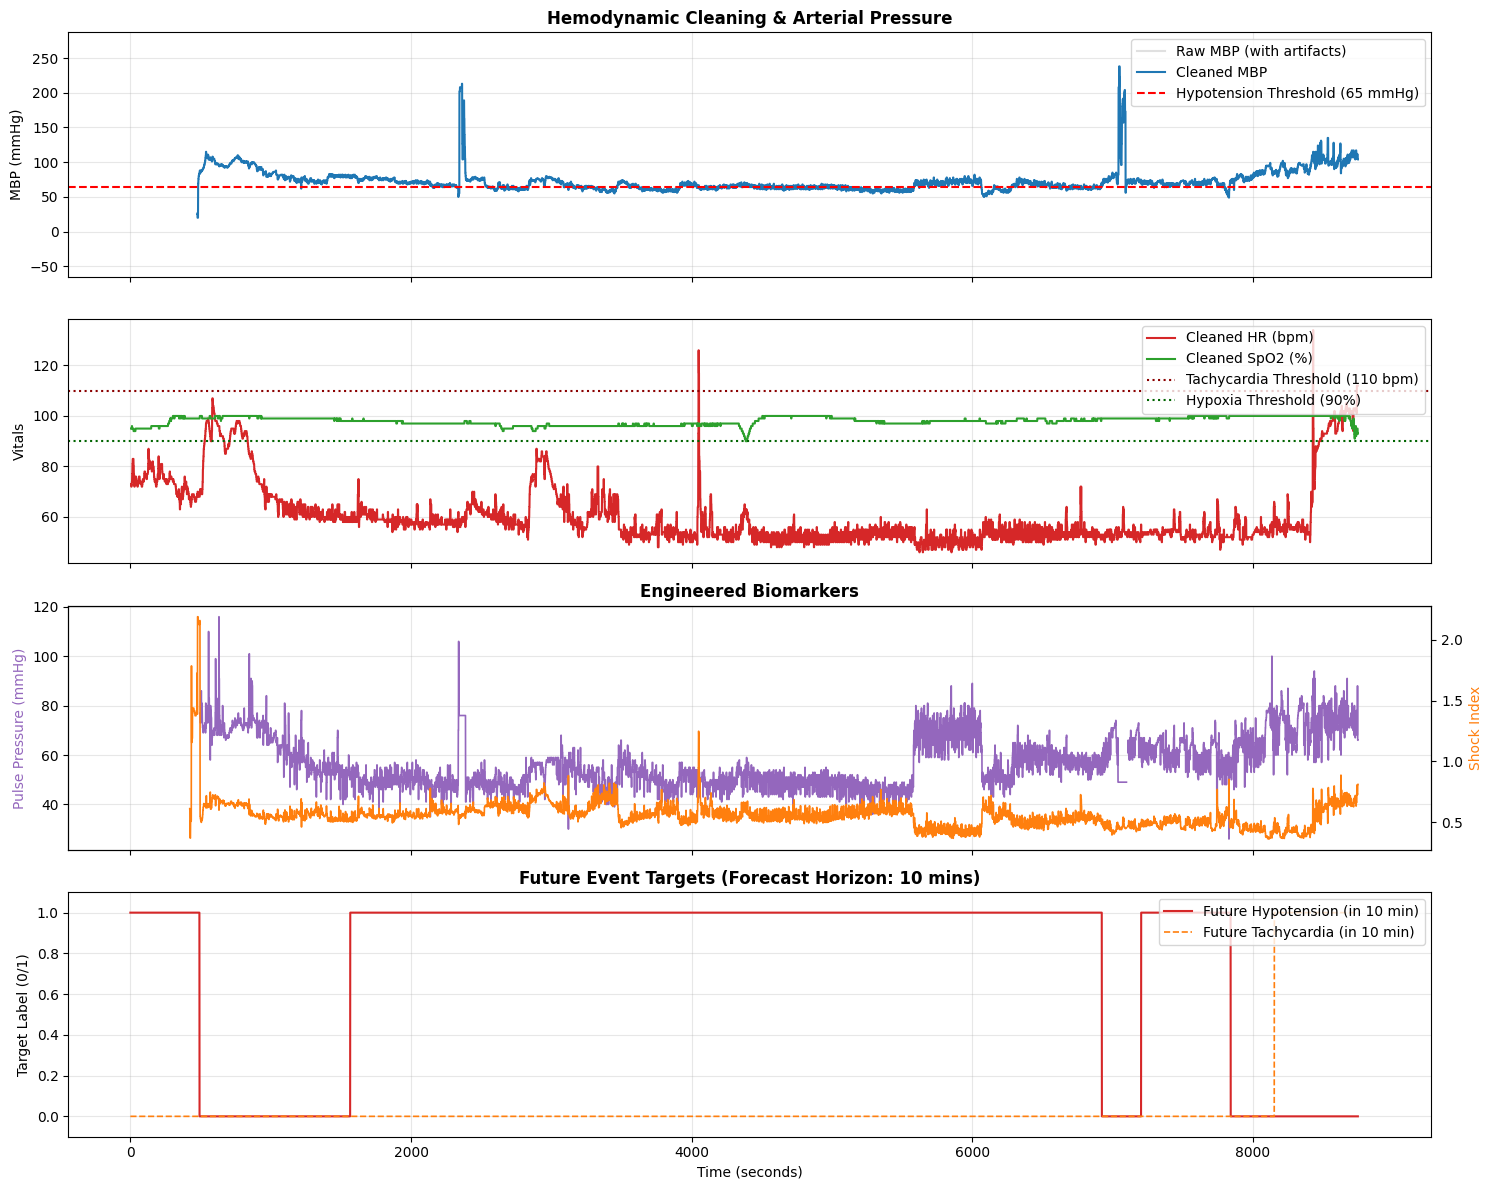

In [4]:
sample_file = csv_files[0] if len(csv_files) > 0 else None
if sample_file:
    print(f"Inspecting sample record: {sample_file}")
    raw_df = pd.read_csv(sample_file)
    
    config = {
        "bounds": bounds,
        "jump_thresholds": max_jump_thresholds,
        "forecast_window": forecast_window,
        "min_valid": min_valid_obs_future
    }
    
    res = process_patient_file(sample_file, output_dir, config)
    print("Processing Result:", res)
    
    # Load cleaned output
    clean_df = pd.read_csv(os.path.join(output_dir, os.path.basename(sample_file)))
    
    # Diagnostic Plots
    fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
    
    # Subplot 1: Blood Pressure Before vs After
    axes[0].plot(raw_df["Time_sec"], raw_df["Solar8000/ART_MBP"], color="lightgray", label="Raw MBP (with artifacts)", alpha=0.7)
    axes[0].plot(clean_df["Time_sec"], clean_df["Solar8000/ART_MBP"], color="#1f77b4", label="Cleaned MBP", lw=1.5)
    axes[0].axhline(65, color="red", linestyle="--", label="Hypotension Threshold (65 mmHg)")
    axes[0].set_ylabel("MBP (mmHg)")
    axes[0].set_title("Hemodynamic Cleaning & Arterial Pressure", fontweight="bold")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)
    
    # Subplot 2: Heart Rate & SpO2
    axes[1].plot(clean_df["Time_sec"], clean_df["Solar8000/HR"], color="#d62728", label="Cleaned HR (bpm)", lw=1.5)
    axes[1].plot(clean_df["Time_sec"], clean_df["Solar8000/PLETH_SPO2"], color="#2ca02c", label="Cleaned SpO2 (%)", lw=1.5)
    axes[1].axhline(110, color="darkred", linestyle=":", label="Tachycardia Threshold (110 bpm)")
    axes[1].axhline(90, color="darkgreen", linestyle=":", label="Hypoxia Threshold (90%)")
    axes[1].set_ylabel("Vitals")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)
    
    # Subplot 3: Engineered Features (Shock Index & Pulse Pressure)
    ax3_twin = axes[2].twinx()
    axes[2].plot(clean_df["Time_sec"], clean_df["Feature_Pulse_Pressure"], color="#9467bd", label="Pulse Pressure (mmHg)", lw=1.2)
    ax3_twin.plot(clean_df["Time_sec"], clean_df["Feature_Shock_Index"], color="#ff7f0e", label="Shock Index (HR/SBP)", lw=1.2)
    axes[2].set_ylabel("Pulse Pressure (mmHg)", color="#9467bd")
    ax3_twin.set_ylabel("Shock Index", color="#ff7f0e")
    axes[2].set_title("Engineered Biomarkers", fontweight="bold")
    axes[2].grid(True, alpha=0.3)
    
    # Subplot 4: Future Event Prediction Labels (10-minute forecast)
    axes[3].plot(clean_df["Time_sec"], clean_df["Future_Hypotension"], color="#d62728", label="Future Hypotension (in 10 min)", lw=1.5)
    axes[3].plot(clean_df["Time_sec"], clean_df["Future_Tachycardia"], color="#ff7f0e", label="Future Tachycardia (in 10 min)", linestyle="--", lw=1.2)
    axes[3].set_ylabel("Target Label (0/1)")
    axes[3].set_xlabel("Time (seconds)")
    axes[3].set_title("Future Event Targets (Forecast Horizon: 10 mins)", fontweight="bold")
    axes[3].legend(loc="upper right")
    axes[3].set_ylim(-0.1, 1.1)
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 4. High-Performance Multi-Core Batch Processing
We use Python's `ProcessPoolExecutor` to utilize all available CPU cores to preprocess and label all patient records in parallel.

In [5]:
from concurrent.futures import ThreadPoolExecutor
config = {
    "bounds": bounds,
    "jump_thresholds": max_jump_thresholds,
    "forecast_window": forecast_window,
    "min_valid": min_valid_obs_future
}

max_workers = min(os.cpu_count() or 4, 16)
print(f"[Batch Processing] Starting parallel execution across {max_workers} worker processes...")

results = []
start_time = time.time()

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {executor.submit(process_patient_file, f, output_dir, config): f for f in csv_files}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Cleaning & Labeling Patient Data"):
        results.append(future.result())

elapsed = time.time() - start_time
print(f"\n[Batch Processing Complete] Processed {len(csv_files)} files in {elapsed:.2f} seconds ({elapsed/60:.2f} minutes).")

[Batch Processing] Starting parallel execution across 16 worker processes...


Cleaning & Labeling Patient Data:   0%|          | 0/3765 [00:00<?, ?it/s]


[Batch Processing Complete] Processed 3765 files in 1051.43 seconds (17.52 minutes).


## 5. Dataset Quality Assurance & Event Prevalence Summary

PREPROCESSING & DATASET HEALTH SUMMARY
Total input files:             3,765
Successfully labeled files:     3,332 (88.5%)
Filtered out / short records:   1
Errors encountered:             432
Total monitored duration:       12,120.1 patient-hours
------------------------------------------------------------
Adverse Event Prevalence (10-minute Forecast Horizon):
  - Hypotension (MBP < 65 mmHg):   31.73% of monitoring time
  - Tachycardia (HR > 110 bpm):    10.59% of monitoring time
  - Hypoxia (SpO2 < 90%):          6.49% of monitoring time


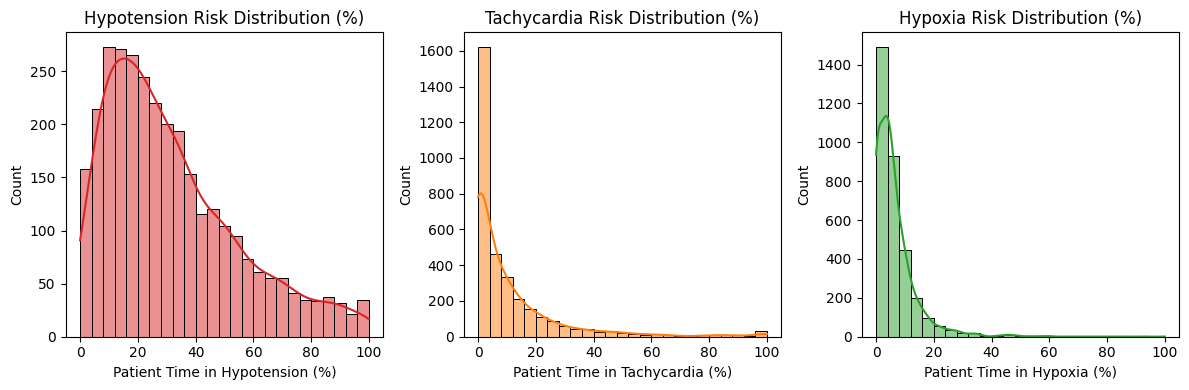

In [6]:
summary_df = pd.DataFrame(results)
success_df = summary_df[summary_df["status"] == "success"]

print("=" * 60)
print("PREPROCESSING & DATASET HEALTH SUMMARY")
print("=" * 60)
print(f"Total input files:             {len(summary_df):,}")
print(f"Successfully labeled files:     {len(success_df):,} ({len(success_df)/max(1, len(summary_df))*100:.1f}%)")
print(f"Filtered out / short records:   {(summary_df['status'] == 'filtered_out').sum():,}")
print(f"Errors encountered:             {(summary_df['status'] == 'error').sum():,}")

if len(success_df) > 0:
    total_hours = (success_df["cleaned_rows"].sum()) / 3600.0
    print(f"Total monitored duration:       {total_hours:,.1f} patient-hours")
    print("-" * 60)
    print("Adverse Event Prevalence (10-minute Forecast Horizon):")
    print(f"  - Hypotension (MBP < 65 mmHg):   {success_df['hypo_rate'].mean()*100:.2f}% of monitoring time")
    print(f"  - Tachycardia (HR > 110 bpm):    {success_df['tachy_rate'].mean()*100:.2f}% of monitoring time")
    print(f"  - Hypoxia (SpO2 < 90%):          {success_df['hypoxia_rate'].mean()*100:.2f}% of monitoring time")
    print("=" * 60)
    
    # Plot Event Prevalence Distributions
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    sns.histplot(success_df["hypo_rate"].dropna() * 100, bins=25, color="#d62728", kde=True)
    plt.title("Hypotension Risk Distribution (%)")
    plt.xlabel("Patient Time in Hypotension (%)")
    
    plt.subplot(1, 3, 2)
    sns.histplot(success_df["tachy_rate"].dropna() * 100, bins=25, color="#ff7f0e", kde=True)
    plt.title("Tachycardia Risk Distribution (%)")
    plt.xlabel("Patient Time in Tachycardia (%)")
    
    plt.subplot(1, 3, 3)
    sns.histplot(success_df["hypoxia_rate"].dropna() * 100, bins=25, color="#2ca02c", kde=True)
    plt.title("Hypoxia Risk Distribution (%)")
    plt.xlabel("Patient Time in Hypoxia (%)")
    
    plt.tight_layout()
    plt.show()